  company_location  average_salary  median_salary  job_count
0      Switzerland   172995.235653       154883.0        819
1           Norway   161036.844384       142293.0        739
2          Denmark   158599.661397       137574.0        759
3    United States   141987.246134       123836.5        776
4            Japan   131289.029650       117281.0        742
5      Netherlands   130924.208556       114268.0        748
6   United Kingdom   130063.897436       114090.0        780
7        Singapore   129558.322835       115789.0        762
8        Australia   125719.941748       114774.0        721
9          Ireland   124034.301189       109428.0        757


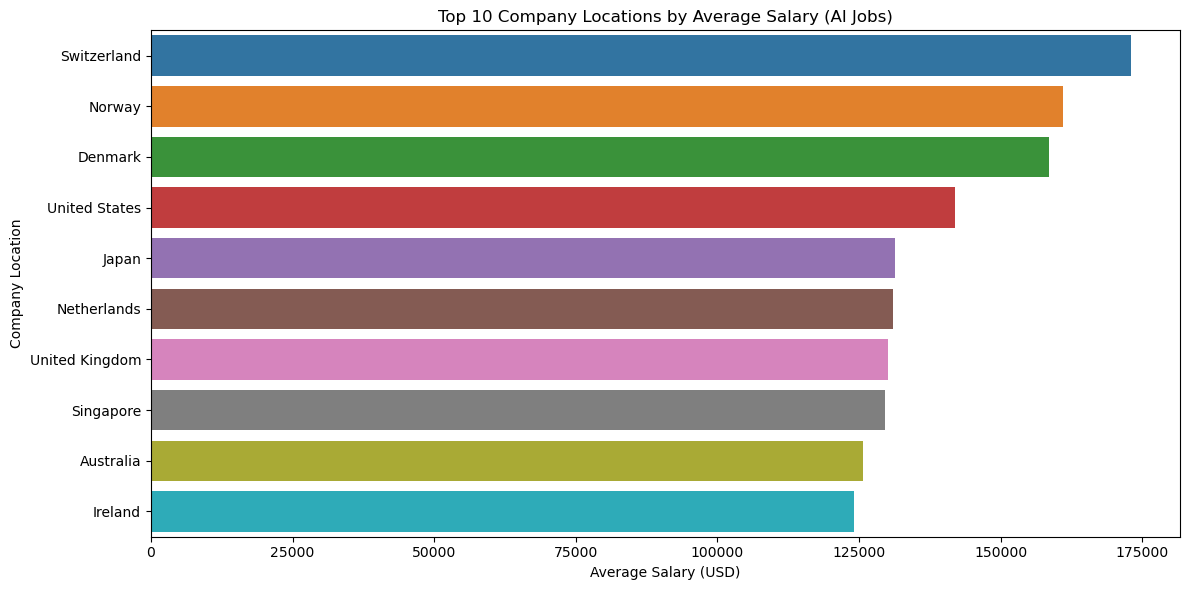

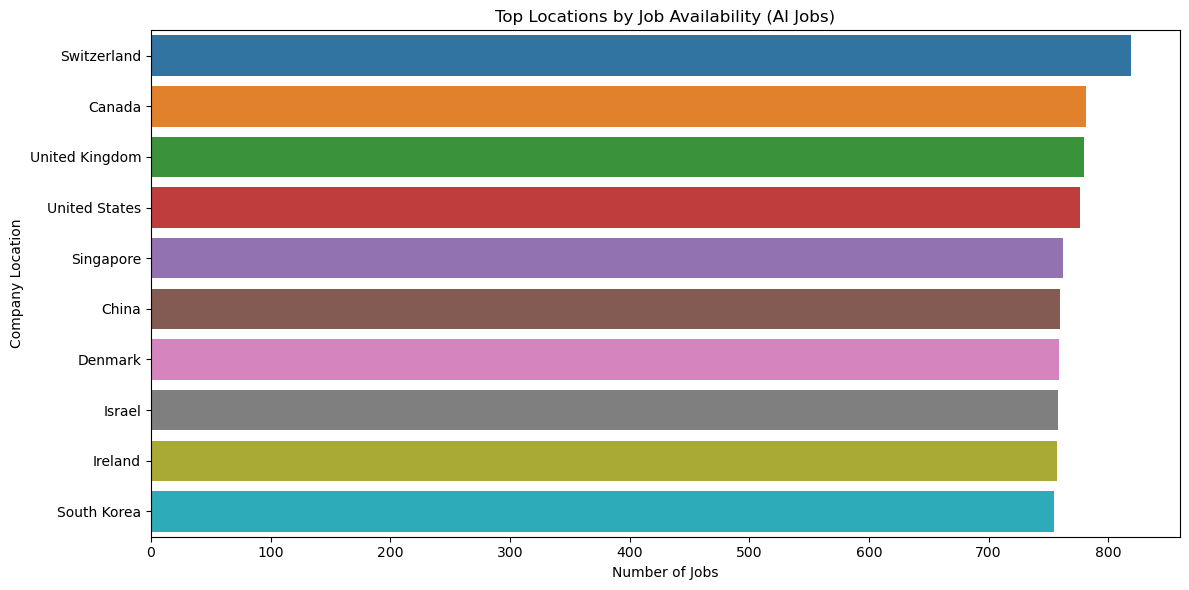

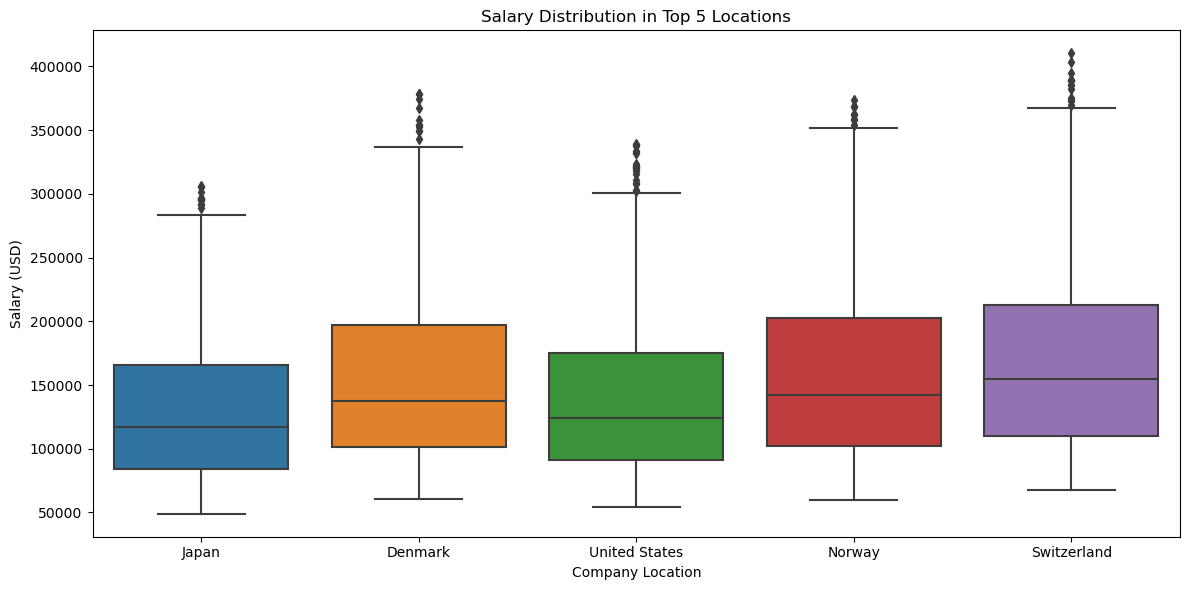


Dataset successfully copied to:
C:\ML ASSIGNMENT 2

RQ5 COMPLETED SUCCESSFULLY
Figures saved in: models/
Tables saved in: tables/
Dataset copied to C:\ML ASSIGNMENT 2


In [3]:

# RQ5: Which company locations offer the highest salaries?


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import shutil

df = pd.read_csv("ai_job_dataset1.csv")

data = df[['company_location', 'salary_usd']].dropna()

models_path = "models"
tables_path = "tables"

os.makedirs(models_path, exist_ok=True)
os.makedirs(tables_path, exist_ok=True)

location_salary = (
    data.groupby('company_location')
    .agg(
        average_salary=('salary_usd', 'mean'),
        median_salary=('salary_usd', 'median'),
        job_count=('salary_usd', 'count')
    )
    .sort_values(by='average_salary', ascending=False)
    .reset_index()
)

print(location_salary.head(10))

table_path = os.path.join(tables_path, "RQ5_location_salary_table.csv")
location_salary.to_csv(table_path, index=False)

plt.figure(figsize=(12,6))

top10 = location_salary.head(10)

sns.barplot(
    data=top10,
    x='average_salary',
    y='company_location'
)

plt.title("Top 10 Company Locations by Average Salary (AI Jobs)")
plt.xlabel("Average Salary (USD)")
plt.ylabel("Company Location")

fig1_path = os.path.join(models_path, "RQ5_top10_locations_salary.png")
plt.tight_layout()
plt.savefig(fig1_path, dpi=300)
plt.show()

plt.figure(figsize=(12,6))

top10_jobs = location_salary.sort_values('job_count', ascending=False).head(10)

sns.barplot(
    data=top10_jobs,
    x='job_count',
    y='company_location'
)

plt.title("Top Locations by Job Availability (AI Jobs)")
plt.xlabel("Number of Jobs")
plt.ylabel("Company Location")

fig2_path = os.path.join(models_path, "RQ5_top_locations_jobcount.png")
plt.tight_layout()
plt.savefig(fig2_path, dpi=300)
plt.show()

top_locations = location_salary.head(5)['company_location']

filtered_data = data[data['company_location'].isin(top_locations)]

plt.figure(figsize=(12,6))

sns.boxplot(
    data=filtered_data,
    x='company_location',
    y='salary_usd'
)

plt.title("Salary Distribution in Top 5 Locations")
plt.xlabel("Company Location")
plt.ylabel("Salary (USD)")

fig3_path = os.path.join(models_path, "RQ5_salary_boxplot.png")
plt.tight_layout()
plt.savefig(fig3_path, dpi=300)
plt.show()

table_path_full = os.path.join(tables_path, "RQ5_full_location_salary_table.csv")
location_salary.to_csv(table_path_full, index=False)

destination_folder = r"C:\ML ASSIGNMENT 2"

os.makedirs(destination_folder, exist_ok=True)

shutil.copy("ai_job_dataset1.csv", destination_folder)

print("\nDataset successfully copied to:")
print(destination_folder)

print("\n====================================")
print("RQ5 COMPLETED SUCCESSFULLY")
print("Figures saved in: models/")
print("Tables saved in: tables/")
print("Dataset copied to C:\\ML ASSIGNMENT 2")
print("====================================")